In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# подключение метода solve_ivp из библиотеки scipy.integrate
from scipy.integrate import solve_ivp


In [2]:
# Ячейка № 2

# задание функции, возвращающей значения
# первых производных СДУ (9.27)
def Deriv(t, x):
    z = np.zeros(2 * N)
    z[0] = x[1]
    z[1] = (
        -Omega[0, 0] * x[0]
        - Omega[1, 0] * (x[0] - x[2])
        + Alpha_m[1, 0] * (x[0] - x[2]) ** 2
        - Alpha_m[0, 0] * x[0] ** 2
        + Beta_m[1, 0] * (x[0] - x[2]) ** 3
        - Beta_m[0, 0] * x[0] ** 3
    )

    K = 2
    for i in range(N - 2):
        z[K] = x[K + 1]
        z[K + 1] = (
            -Omega[i + 1, i + 1] * (x[K] - x[K - 2])
            - Omega[i + 2, i + 1] * (x[K] - x[K + 2])
            + Alpha_m[i + 2, i + 1] * (x[K] - x[K + 2]) ** 2
            - Alpha_m[i + 1, i + 1] * (x[K] - x[K - 2]) ** 2
            + Beta_m[i + 2, i + 1] * (x[K] - x[K + 2]) ** 3
            - Beta_m[i + 1, i + 1] * (x[K] - x[K - 2]) ** 3
        )
        K = K + 2
    z[2 * N - 2] = x[2 * N - 1]
    z[2 * N - 1] = (
        -Omega[N - 1, N - 1] * (x[2 * N - 2] - x[2 * N - 4])
        - Omega[N, N - 1] * x[2 * N - 2]
        + Alpha_m[N, N - 1] * x[2 * N - 2] ** 2
        - Alpha_m[N - 1, N - 1] * (x[2 * N - 2] - x[2 * N - 4]) ** 2
        + Beta_m[N, N - 1] * x[K - 2] ** 3
        - Beta_m[N - 1, N - 1] * (x[2 * N - 2] - x[2 * N - 4]) ** 3
    )

    return z

In [ ]:
# Ячейка № 3

# задание числа масс
# колебательной системы
N = 16

# задание значений масс
# колебательной системы
m = np.ones(N)

# задание жесткостей пружин
# колебательной системы
k = np.ones(N + 1)


# вычисление матрицы Omega
Omega = np.zeros([N + 1, N])

for i in range(N + 1):
    for j in range(N):
        Omega[i, j] = k[i] / m[j]

# инициализация массива omega,
# используемого для хранения
# матрицы omega, вычисляемой
# в соответствии с (9.8)
omega = np.zeros([N, N])

# вычисление вычисление значений
# элементов матрицы Omega
# в соответствие с (9.8)
for i in range(N):
    if i == 0:
        omega[0, 0] = Omega[0, 0] + Omega[1, 0]
        omega[0, 1] = -Omega[1, 0]
    if i > 0:
        if i < N - 1:
            omega[i, i - 1] = -Omega[i, i]
            omega[i, i] = Omega[i, i] + Omega[i + 1, i]
            omega[i, i + 1] = -Omega[i + 1, i]
        else:
            omega[i, i - 1] = -Omega[i, i]
            omega[i, i] = Omega[i, i] + Omega[i + 1, i]

# задание коэффициентов
# квадратических составляющих нелинейностей
# пружин колебательной системы
alpha = 0.2 * np.ones(N + 1)

# инициализация массива Alpha_m,
# используемого для хранения отношений
# кадратических составляющих нелинейностей
# жесткостей пружин к массам тел
# колебательной системы
Alpha_m = np.zeros([N + 1, N])

# вычисление значений отношений
# коэффициентов квадратичных нелинейностей
# к массам грузов
for i in range(N + 1):
    for j in range(N):
        Alpha_m[i, j] = alpha[i] / m[j]

# задание коэффициентов
# кубических составляющих нелинейностей
# пружин колебательной системы
beta = 0.1 * np.ones(N + 1)

Beta_m = np.zeros([N + 1, N])

# вычисление значений отношений
# коэффициентов кубических нелинейностей
# к массам грузов
for i in range(N + 1):
    for j in range(N):
        Beta_m[i, j] = beta[i] / m[j]

# вычисление собственных чисел и
# собственных векторов матрицы Omеga,
# элементы которой вычисляются
# в соответствие с (9.4)
Teta, Sigma = np.linalg.eig(omega)

# вычисление матрицы, обратной
# матрице omega
S = np.linalg.inv(omega)

# задание параметров
# выбранной моды нормальных колебаний
An = np.zeros(N)
Vn = np.zeros(N)

Nn = 0  # выбор первой моды нормальных колебаний
An[Nn] = 1  # задаем начальное значение
# выбранной моды
# нормальных колебаний

# вычисление значений смещений масс
# колебательной системы от положений равновесия
#  в момент времени t = 0
R0 = np.zeros(2 * N)
R0 = np.dot(Sigma, An)

# вычисление значений скоростей
# масс колебательной системы
# в момент времени t=0
v0 = np.dot(Sigma, Vn)

# инициализация и заполнение массива Nu,
# используемого для хранения начальных условий
# в формате, используемым в функции Solv_inv
Nu = np.zeros(2 * N)
for i in range(N):
    Nu[2 * i] = R0[i]
    Nu[2 * i + 1] = v0[i]

# задание шага
# координатной сетки
Tfin = 100
Np = 2**21
dt = Tfin / Np

# вычисление численного решения СДУ (9.27)
Solv = solve_ivp(Deriv, [0, Tfin], Nu, method="RK45", t_eval=np.linspace(0, Tfin, Np))

In [4]:
# Ячейка № 4

# вычисление на основе численного решения СДУ (9.37)
# зависимостей нормальных координат
# и их скоростей от времени

# инициализация массива Х,
# используемого для хранения
# мгновенных значений
# зависимостей смещений
# нормальных мод колебательной системы
# от времени
X = np.zeros([Np, N])

# инициализация массива Х,
# используемого для хранения
# мгновенных значений
# зависимостей скорости
# нормальных мод колебательной системы
# от времени
V = np.zeros([Np, N])

# вычисление собственных чисел и
# собственных векторов матрицы omеga
Teta, Sigma = np.linalg.eig(omega)

# инициализация массива Teta_M,
# используемого для создания
# диагональной матрицы, в которой
# на главной диагонали размещаются с
# соответствующие собственные числа матрицы B
Teta_M = np.zeros([N, N])

# размещение на главной диагонали матрицы Teta_M
# соответствующих собственных чисел матрицы B
for i in range(N):
    Teta_M[i, i] = np.sqrt(Teta[i])

# вычисление матрицы,
# обратной матрице Sigma
Sx = np.linalg.inv(Sigma)

# перемещение численного
# решения СДУ (9.30) из массива размерностью N x Np
# в массив размерностью Np x N
Y1 = Solv.y.T

# инициализация массива X2,
# используемого для хранения мгновенных значений
# смещений от положения равновесия
# масс колебательной системы
X2 = np.zeros([Np, N])

# инициализация массива V2,
# используемого для хранения мгновенных значений
# скоростей масс колебательной системы
V2 = np.zeros([Np, N])

# перемещение значений координат и
# скоростей масс колебательной системы
# в массивы X2 и V2, соответственно
for i in range(N):
    X2[:, i] = Y1[:, 2 * i]
    V2[:, i] = Y1[:, 2 * i + 1]


# инициализация массива Xn,
# используемого для хранения
# координат мгновенных значений
# нормальных колебаний
# масс колебательной системы
Xn = np.zeros([Np, N])

# инициализация массива Vn,
# используемого для хранения мгновенных значений
# скоростей нормальных колебаний
Vn = np.zeros([Np, N])

# вычисление мгновенных значений
# координат и скоростей колебательной системы
# в соответствие с (9.31)
for i in range(Np):
    Xn[i, :] = np.dot(Sx, X2[i, :])
    Vn[i, :] = np.dot(Sx, V2[i, :])

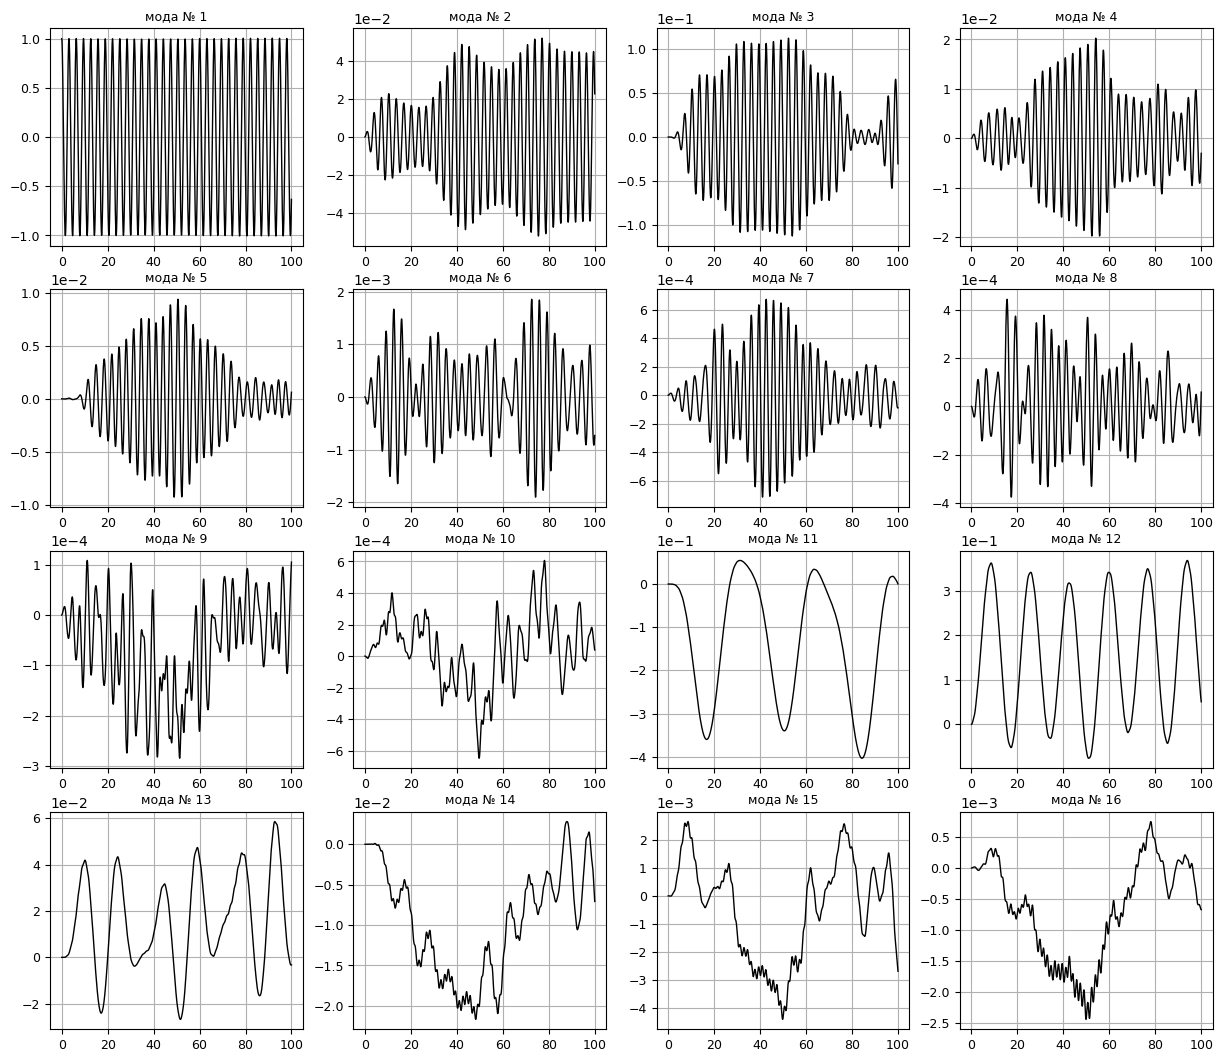

In [5]:
# Ячейка # 5

# визуализация мгновенных значений
# зависимостей координат
# мод нормальных колебаний
# от времени

# визуализация зависимостей полной энергии
# масс колебательной системы от времени
fig = plt.figure(figsize=(15, 13))
K = 0
Ng = 16
for i in range(Ng):
    Str = "мода № " + str(K + 1)
    ax = fig.add_subplot(4, 4, K + 1)
    ax.plot(Solv.t[:], Xn[:, K], "-k", lw=1)
    ax.grid(True)
    sf = ScalarFormatter()
    sf.set_powerlimits((-1, 1))
    ax.yaxis.set_major_formatter(sf)
    ax.set_title(Str, fontsize=9)
    ax.tick_params(labelsize=9)
    K = K + 1

plt.show()

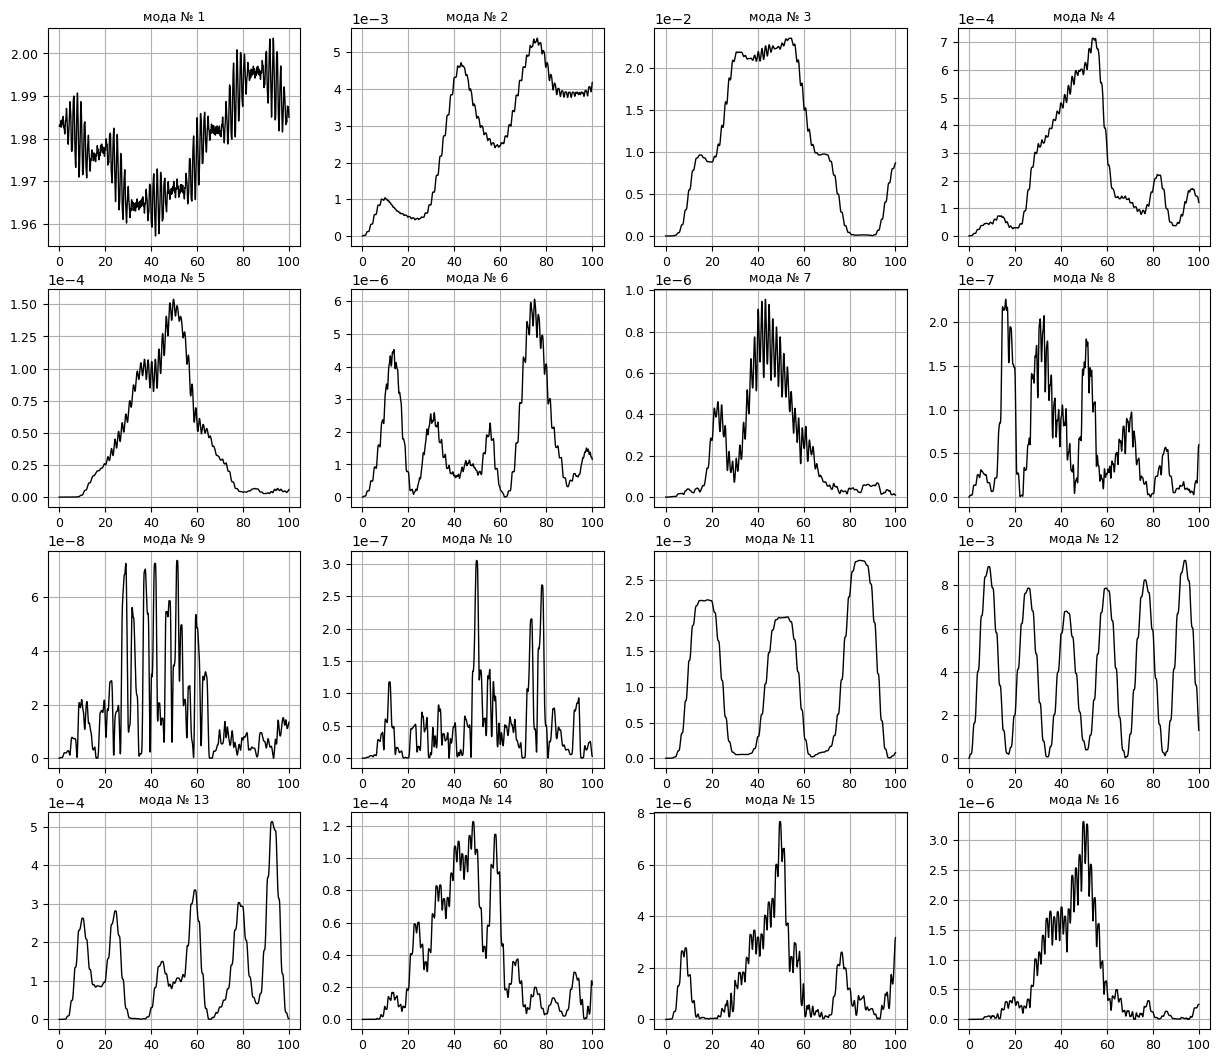

In [6]:
# Ячейка № 6

# вычисление и визуализация
# мгновенных значений полной энергии
# мод колебательной системы от времени

# инициализация массива En,
# используемого для хранения
# мгновенных значений полной энергии
# колебательной системы
En_norm = np.zeros([Np, N])

# вычисление мгновенных значений
# полной энергии масс
#  колебательной системы
for j in range(Np):
    En_norm[j, :] = 0.5 * m[:] * (Vn[j, :] ** 2 + Teta[:] * Xn[j, :] ** 2)

# визуализация зависимостей полной энергии
# масс колебательной системы от времени
fig = plt.figure(figsize=(15, 13))
K = 0
Ng = 16
for i in range(Ng):
    Str = "мода № " + str(K + 1)
    ax = fig.add_subplot(4, 4, K + 1)
    ax.plot(Solv.t[:], En_norm[:, K], "-k", lw=1)
    ax.grid(True)
    sf = ScalarFormatter()
    sf.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(sf)
    ax.set_title(Str, fontsize=9)
    ax.tick_params(labelsize=9)
    K = K + 1

plt.show()

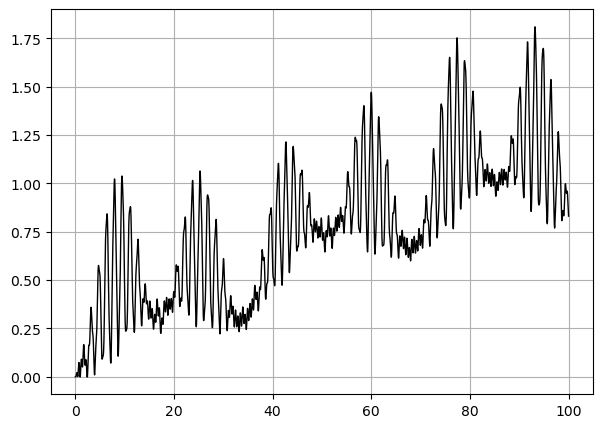

In [7]:
# Ячейка № 7

# вычисление и визуализация
# мгновенных значений
# точности показателя
# выполнения закона сохранения энергии,
# вычисленной на основе значений
# кинематических характеристик мод
# нормальных колебаний

# вычисление мгновенных значений
# полной энергии колебательной системы
Efull_norm = np.sum(En_norm, axis=1)


# визуализация абсолютных отклонений с течением времени
# мгновенных значений энергии
# колебательной системы от нее начального значения
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot()
ax.plot(
    Solv.t[:], abs(Efull_norm[:] - Efull_norm[0]) / Efull_norm[0] * 10**2, "-k", lw=1
)
ax.grid(True)

plt.show()